# Limits: The Foundation of Calculus

## Why Limits Matter

Limits are the foundation upon which all of calculus is built. They allow us to:
- Define derivatives (instantaneous rates of change)
- Define integrals (accumulation)
- Handle infinity rigorously
- Deal with discontinuities and undefined points

**The Big Idea**: Limits let us ask "what value does a function *approach* as we get closer and closer to a point?"

This is different from asking "what value does the function have at that point?" - a subtle but crucial distinction.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Intuitive Understanding of Limits

### Example: A Simple Limit

Consider the function: $f(x) = \frac{x^2 - 1}{x - 1}$

What happens at $x = 1$? Direct substitution gives $\frac{0}{0}$ - undefined!

But what if we approach $x = 1$ from both sides?

In [3]:
# Let's investigate numerically
def f(x):
    """f(x) = (x^2 - 1)/(x - 1)"""
    return (x**2 - 1) / (x - 1)

# Approaching from the left (x < 1)
left_values = [0.9, 0.99, 0.999, 0.9999, 0.99999]
# Approaching from the right (x > 1)
right_values = [1.1, 1.01, 1.001, 1.0001, 1.00001]

print("Approaching x = 1 from the LEFT:")
for x in left_values:
    print(f"  f({x}) = {f(x):.6f}")

print("\nApproaching x = 1 from the RIGHT:")
for x in right_values:
    print(f"  f({x}) = {f(x):.6f}")

print("\nThe limit appears to be: 2")

Approaching x = 1 from the LEFT:
  f(0.9) = 1.900000
  f(0.99) = 1.990000
  f(0.999) = 1.999000
  f(0.9999) = 1.999900
  f(0.99999) = 1.999990

Approaching x = 1 from the RIGHT:
  f(1.1) = 2.100000
  f(1.01) = 2.010000
  f(1.001) = 2.001000
  f(1.0001) = 2.000100
  f(1.00001) = 2.000010

The limit appears to be: 2


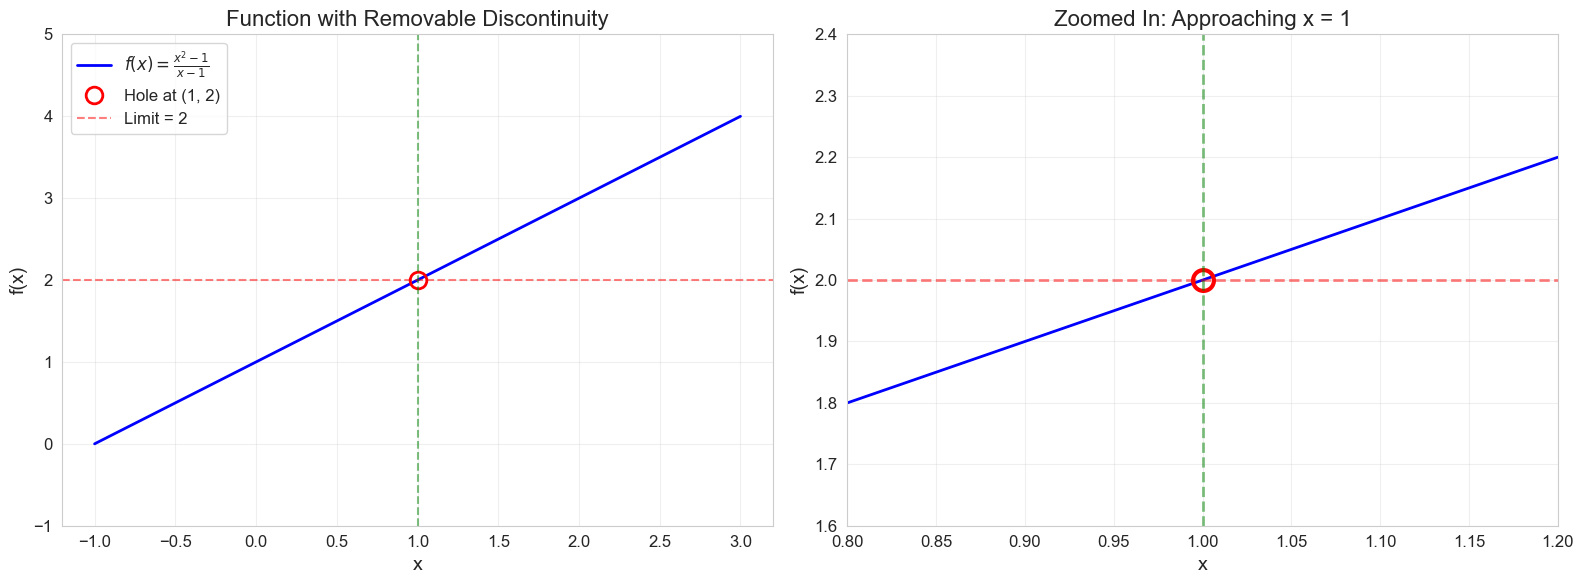

Notice: Even though f(1) is undefined, the limit as x→1 equals 2
Algebraically: (x²-1)/(x-1) = (x+1)(x-1)/(x-1) = x+1 for x≠1


In [4]:
# Visualize this behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: The function with a hole at x=1
x = np.linspace(-1, 3, 1000)
x = x[x != 1]  # Remove x=1
y = (x**2 - 1) / (x - 1)

ax1.plot(x, y, 'b-', linewidth=2, label=r'$f(x) = \frac{x^2-1}{x-1}$')
ax1.plot(1, 2, 'ro', markersize=12, fillstyle='none', markeredgewidth=2, 
         label='Hole at (1, 2)')
ax1.axhline(y=2, color='r', linestyle='--', alpha=0.5, label='Limit = 2')
ax1.axvline(x=1, color='g', linestyle='--', alpha=0.5)
ax1.set_xlabel('x', fontsize=14)
ax1.set_ylabel('f(x)', fontsize=14)
ax1.set_title('Function with Removable Discontinuity', fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1, 5)

# Right plot: Zooming in on x=1
x_zoom = np.linspace(0.8, 1.2, 1000)
x_zoom = x_zoom[np.abs(x_zoom - 1) > 0.001]  # Remove points too close to 1
y_zoom = (x_zoom**2 - 1) / (x_zoom - 1)

ax2.plot(x_zoom, y_zoom, 'b-', linewidth=2)
ax2.plot(1, 2, 'ro', markersize=15, fillstyle='none', markeredgewidth=3)
ax2.axhline(y=2, color='r', linestyle='--', alpha=0.5, linewidth=2)
ax2.axvline(x=1, color='g', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_xlabel('x', fontsize=14)
ax2.set_ylabel('f(x)', fontsize=14)
ax2.set_title('Zoomed In: Approaching x = 1', fontsize=16)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.8, 1.2)
ax2.set_ylim(1.6, 2.4)

plt.tight_layout()
plt.show()

print("Notice: Even though f(1) is undefined, the limit as x→1 equals 2")
print("Algebraically: (x²-1)/(x-1) = (x+1)(x-1)/(x-1) = x+1 for x≠1")

### Formal Definition (ε-δ)

We write: $\lim_{x \to a} f(x) = L$

**Formal meaning**: For every distance $\varepsilon > 0$ (however small), there exists a distance $\delta > 0$ such that:

If $0 < |x - a| < \delta$, then $|f(x) - L| < \varepsilon$

**Intuitive meaning**: We can make $f(x)$ as close as we want to $L$ by making $x$ sufficiently close to $a$.

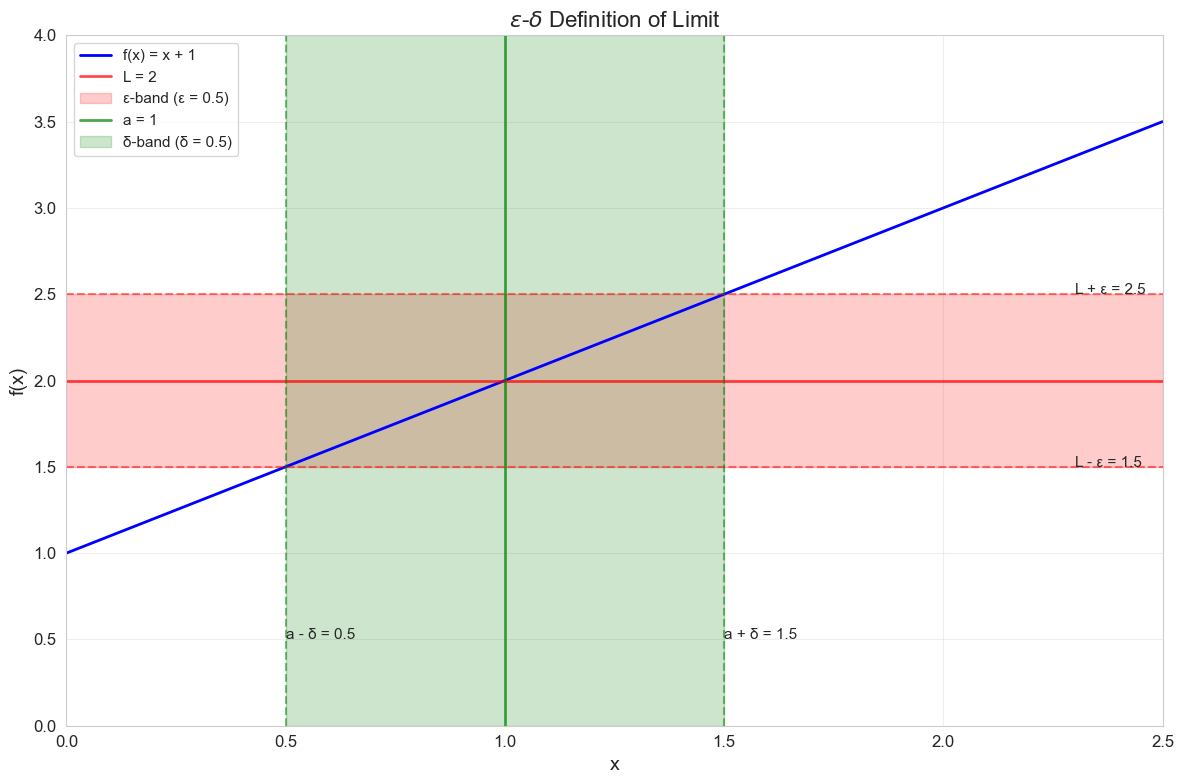

If x is within δ = 0.5 of a = 1, then f(x) is within ε = 0.5 of L = 2


In [5]:
# Visualize epsilon-delta definition
def visualize_epsilon_delta(epsilon):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Function: f(x) = x + 1 (simplified version of our limit)
    x = np.linspace(0, 2.5, 1000)
    y = x + 1
    
    a, L = 1, 2  # Point and limit
    delta = epsilon  # For this simple function, δ = ε
    
    # Plot function
    ax.plot(x, y, 'b-', linewidth=2, label='f(x) = x + 1')
    
    # Epsilon band (horizontal)
    ax.axhline(y=L, color='r', linestyle='-', linewidth=2, alpha=0.7, label=f'L = {L}')
    ax.axhspan(L - epsilon, L + epsilon, alpha=0.2, color='red', 
               label=f'ε-band (ε = {epsilon})')
    ax.axhline(y=L + epsilon, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=L - epsilon, color='r', linestyle='--', alpha=0.5)
    
    # Delta band (vertical)
    ax.axvline(x=a, color='g', linestyle='-', linewidth=2, alpha=0.7, label=f'a = {a}')
    ax.axvspan(a - delta, a + delta, alpha=0.2, color='green', 
               label=f'δ-band (δ = {delta})')
    ax.axvline(x=a + delta, color='g', linestyle='--', alpha=0.5)
    ax.axvline(x=a - delta, color='g', linestyle='--', alpha=0.5)
    
    # Annotations
    ax.annotate(f'L + ε = {L + epsilon}', xy=(2.3, L + epsilon), fontsize=11)
    ax.annotate(f'L - ε = {L - epsilon}', xy=(2.3, L - epsilon), fontsize=11)
    ax.annotate(f'a + δ = {a + delta}', xy=(a + delta, 0.5), fontsize=11)
    ax.annotate(f'a - δ = {a - delta}', xy=(a - delta, 0.5), fontsize=11)
    
    ax.set_xlabel('x', fontsize=14)
    ax.set_ylabel('f(x)', fontsize=14)
    ax.set_title(r'$\epsilon$-$\delta$ Definition of Limit', fontsize=16)
    ax.legend(fontsize=11, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(0, 4)
    
    plt.tight_layout()
    plt.show()
    
    print(f"If x is within δ = {delta} of a = {a}, then f(x) is within ε = {epsilon} of L = {L}")

# Try different epsilon values
visualize_epsilon_delta(0.5)

## 2. One-Sided Limits

Sometimes the behavior from the left and right differ:

- **Left-hand limit**: $\lim_{x \to a^-} f(x)$ (approaching from x < a)
- **Right-hand limit**: $\lim_{x \to a^+} f(x)$ (approaching from x > a)

**The limit exists** if and only if both one-sided limits exist and are equal.

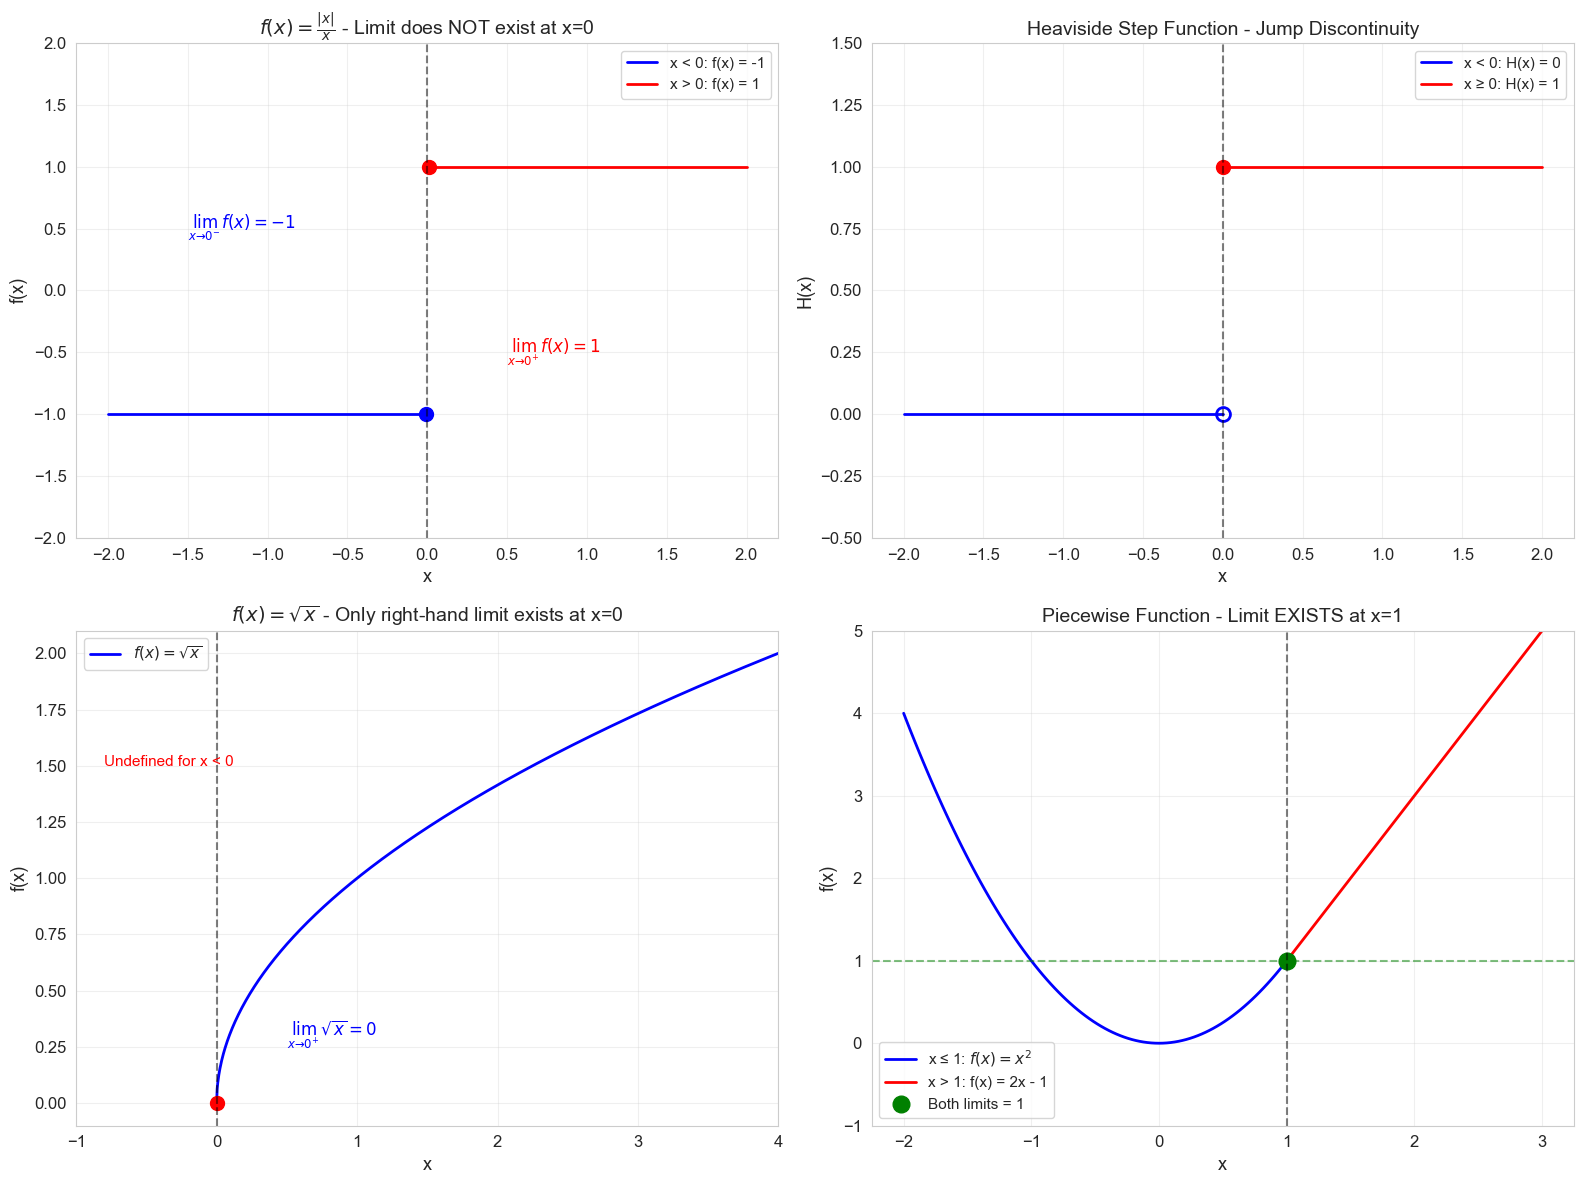

In [6]:
# Example: Absolute value function divided by x
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Example 1: |x|/x - limit does NOT exist at x=0
x_neg = np.linspace(-2, -0.01, 100)
x_pos = np.linspace(0.01, 2, 100)
y_neg = np.abs(x_neg) / x_neg
y_pos = np.abs(x_pos) / x_pos

axes[0, 0].plot(x_neg, y_neg, 'b-', linewidth=2, label='x < 0: f(x) = -1')
axes[0, 0].plot(x_pos, y_pos, 'r-', linewidth=2, label='x > 0: f(x) = 1')
axes[0, 0].plot(-0.01, -1, 'bo', markersize=10)
axes[0, 0].plot(0.01, 1, 'ro', markersize=10)
axes[0, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('x', fontsize=13)
axes[0, 0].set_ylabel('f(x)', fontsize=13)
axes[0, 0].set_title(r'$f(x) = \frac{|x|}{x}$ - Limit does NOT exist at x=0', fontsize=14)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-2, 2)
axes[0, 0].text(0.5, -0.5, r'$\lim_{x \to 0^+} f(x) = 1$', fontsize=12, color='red')
axes[0, 0].text(-1.5, 0.5, r'$\lim_{x \to 0^-} f(x) = -1$', fontsize=12, color='blue')

# Example 2: Step function (Heaviside)
x_neg2 = np.linspace(-2, 0, 100)
x_pos2 = np.linspace(0, 2, 100)
y_neg2 = np.zeros_like(x_neg2)
y_pos2 = np.ones_like(x_pos2)

axes[0, 1].plot(x_neg2, y_neg2, 'b-', linewidth=2, label='x < 0: H(x) = 0')
axes[0, 1].plot(x_pos2, y_pos2, 'r-', linewidth=2, label='x ≥ 0: H(x) = 1')
axes[0, 1].plot(0, 0, 'bo', markersize=10, fillstyle='none', markeredgewidth=2)
axes[0, 1].plot(0, 1, 'ro', markersize=10)
axes[0, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('x', fontsize=13)
axes[0, 1].set_ylabel('H(x)', fontsize=13)
axes[0, 1].set_title('Heaviside Step Function - Jump Discontinuity', fontsize=14)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-0.5, 1.5)

# Example 3: Square root (one-sided limit)
x_sqrt = np.linspace(0, 4, 1000)
y_sqrt = np.sqrt(x_sqrt)

axes[1, 0].plot(x_sqrt, y_sqrt, 'b-', linewidth=2, label=r'$f(x) = \sqrt{x}$')
axes[1, 0].plot(0, 0, 'ro', markersize=10)
axes[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('x', fontsize=13)
axes[1, 0].set_ylabel('f(x)', fontsize=13)
axes[1, 0].set_title(r'$f(x) = \sqrt{x}$ - Only right-hand limit exists at x=0', fontsize=14)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(-1, 4)
axes[1, 0].text(0.5, 0.3, r'$\lim_{x \to 0^+} \sqrt{x} = 0$', fontsize=12, color='blue')
axes[1, 0].text(-0.8, 1.5, 'Undefined for x < 0', fontsize=11, color='red')

# Example 4: Piecewise function where limits match
x_piece1 = np.linspace(-2, 1, 100)
x_piece2 = np.linspace(1, 3, 100)
y_piece1 = x_piece1**2
y_piece2 = 2*x_piece2 - 1

axes[1, 1].plot(x_piece1, y_piece1, 'b-', linewidth=2, label=r'x ≤ 1: $f(x) = x^2$')
axes[1, 1].plot(x_piece2, y_piece2, 'r-', linewidth=2, label='x > 1: f(x) = 2x - 1')
axes[1, 1].plot(1, 1, 'go', markersize=12, label='Both limits = 1')
axes[1, 1].axvline(x=1, color='black', linestyle='--', alpha=0.5)
axes[1, 1].axhline(y=1, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('x', fontsize=13)
axes[1, 1].set_ylabel('f(x)', fontsize=13)
axes[1, 1].set_title('Piecewise Function - Limit EXISTS at x=1', fontsize=14)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(-1, 5)

plt.tight_layout()
plt.show()

## 3. Infinite Limits and Limits at Infinity

### Infinite Limits: $\lim_{x \to a} f(x) = \pm\infty$

The function grows without bound as x approaches a. This describes **vertical asymptotes**.

### Limits at Infinity: $\lim_{x \to \pm\infty} f(x) = L$

The function approaches a value L as x grows without bound. This describes **horizontal asymptotes**.

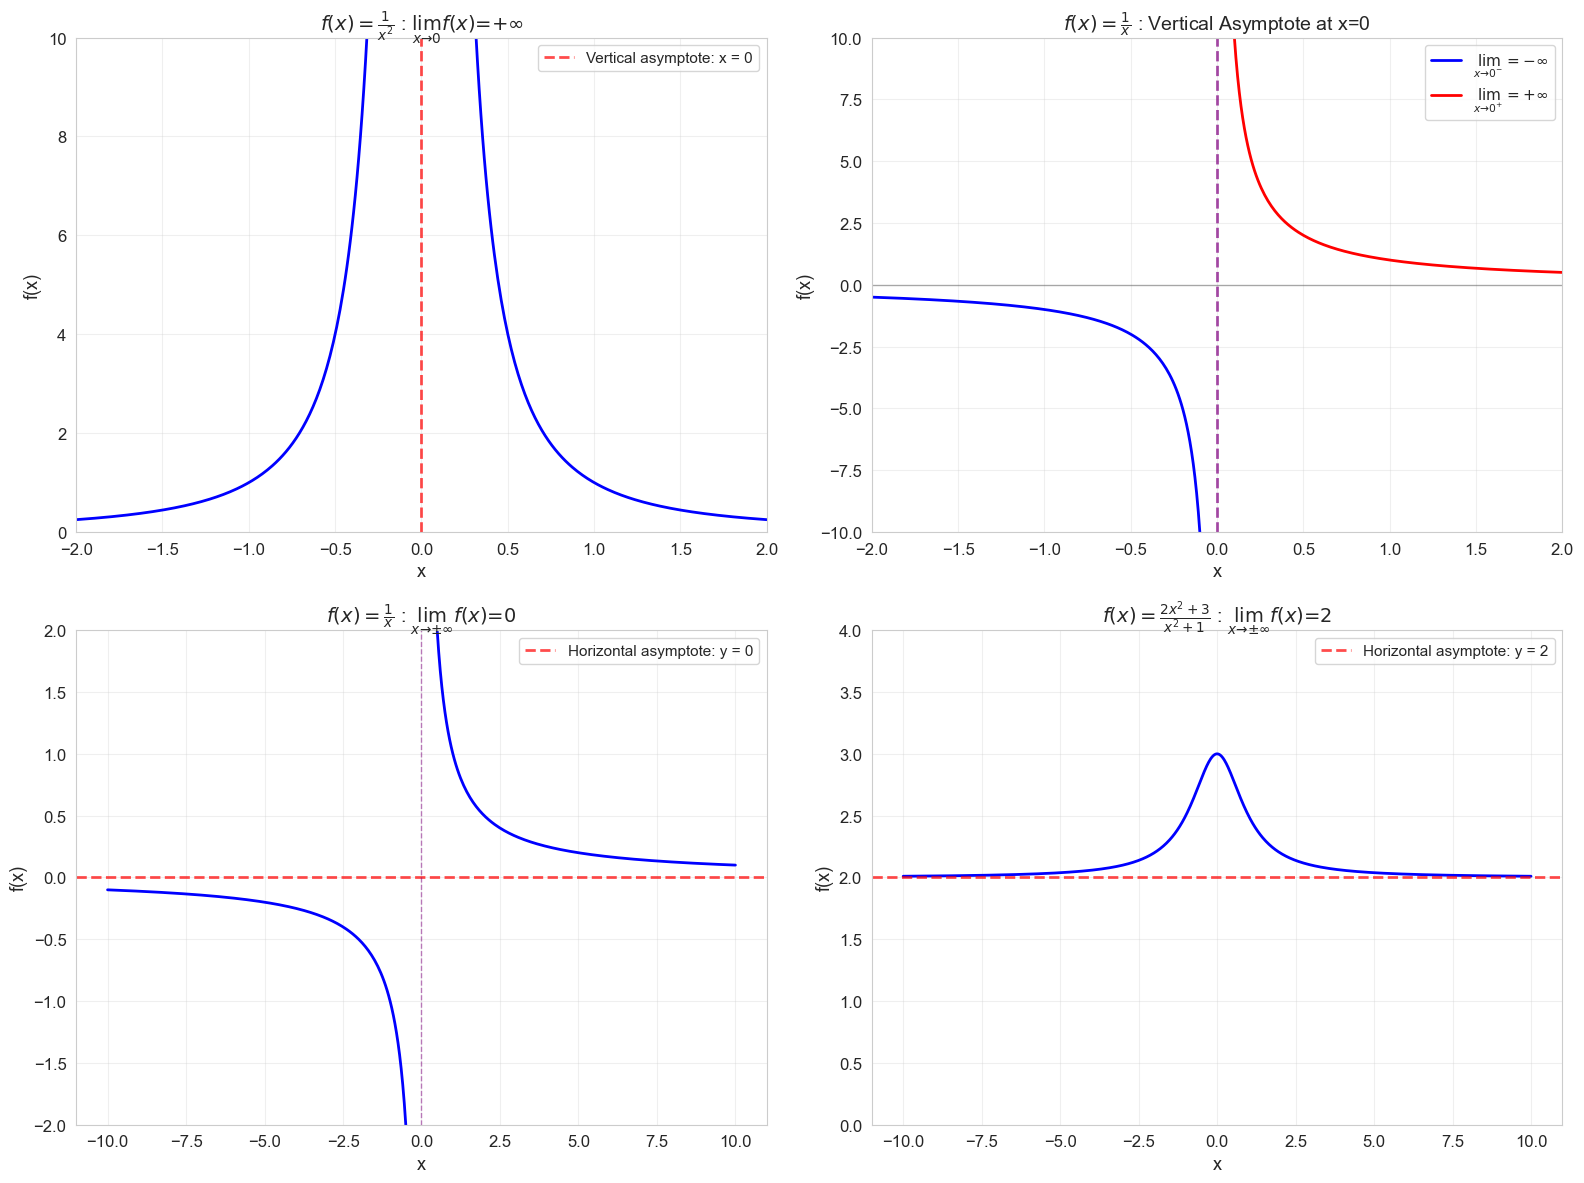

Key Insight for Limits at Infinity of Rational Functions:
Compare degrees of numerator and denominator polynomials:
  - If deg(num) < deg(den): limit = 0
  - If deg(num) = deg(den): limit = ratio of leading coefficients
  - If deg(num) > deg(den): limit = ±∞


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Example 1: Infinite limit - 1/x^2
x1_left = np.linspace(-2, -0.05, 200)
x1_right = np.linspace(0.05, 2, 200)
y1_left = 1 / x1_left**2
y1_right = 1 / x1_right**2

axes[0, 0].plot(x1_left, y1_left, 'b-', linewidth=2)
axes[0, 0].plot(x1_right, y1_right, 'b-', linewidth=2)
axes[0, 0].axvline(x=0, color='r', linestyle='--', linewidth=2, alpha=0.7, 
                   label='Vertical asymptote: x = 0')
axes[0, 0].set_xlabel('x', fontsize=13)
axes[0, 0].set_ylabel('f(x)', fontsize=13)
axes[0, 0].set_title(r'$f(x) = \frac{1}{x^2}$ : $\lim_{x \to 0} f(x) = +\infty$', fontsize=14)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(0, 10)
axes[0, 0].set_xlim(-2, 2)

# Example 2: Infinite limit - 1/x (different from left and right)
x2_left = np.linspace(-2, -0.05, 200)
x2_right = np.linspace(0.05, 2, 200)
y2_left = 1 / x2_left
y2_right = 1 / x2_right

axes[0, 1].plot(x2_left, y2_left, 'b-', linewidth=2, label=r'$\lim_{x \to 0^-} = -\infty$')
axes[0, 1].plot(x2_right, y2_right, 'r-', linewidth=2, label=r'$\lim_{x \to 0^+} = +\infty$')
axes[0, 1].axvline(x=0, color='purple', linestyle='--', linewidth=2, alpha=0.7)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0, 1].set_xlabel('x', fontsize=13)
axes[0, 1].set_ylabel('f(x)', fontsize=13)
axes[0, 1].set_title(r'$f(x) = \frac{1}{x}$ : Vertical Asymptote at x=0', fontsize=14)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-10, 10)
axes[0, 1].set_xlim(-2, 2)

# Example 3: Limit at infinity - 1/x
x3 = np.linspace(-10, -0.1, 200)
x4 = np.linspace(0.1, 10, 200)
y3 = 1 / x3
y4 = 1 / x4

axes[1, 0].plot(x3, y3, 'b-', linewidth=2)
axes[1, 0].plot(x4, y4, 'b-', linewidth=2)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.7, 
                   label='Horizontal asymptote: y = 0')
axes[1, 0].axvline(x=0, color='purple', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].set_xlabel('x', fontsize=13)
axes[1, 0].set_ylabel('f(x)', fontsize=13)
axes[1, 0].set_title(r'$f(x) = \frac{1}{x}$ : $\lim_{x \to \pm\infty} f(x) = 0$', fontsize=14)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(-2, 2)

# Example 4: Rational function with horizontal asymptote
x5 = np.linspace(-10, 10, 1000)
y5 = (2*x5**2 + 3) / (x5**2 + 1)

axes[1, 1].plot(x5, y5, 'b-', linewidth=2)
axes[1, 1].axhline(y=2, color='r', linestyle='--', linewidth=2, alpha=0.7, 
                   label='Horizontal asymptote: y = 2')
axes[1, 1].set_xlabel('x', fontsize=13)
axes[1, 1].set_ylabel('f(x)', fontsize=13)
axes[1, 1].set_title(r'$f(x) = \frac{2x^2+3}{x^2+1}$ : $\lim_{x \to \pm\infty} f(x) = 2$', fontsize=14)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 4)

plt.tight_layout()
plt.show()

print("Key Insight for Limits at Infinity of Rational Functions:")
print("Compare degrees of numerator and denominator polynomials:")
print("  - If deg(num) < deg(den): limit = 0")
print("  - If deg(num) = deg(den): limit = ratio of leading coefficients")
print("  - If deg(num) > deg(den): limit = ±∞")

## 4. Limit Laws

If $\lim_{x \to a} f(x) = L$ and $\lim_{x \to a} g(x) = M$, then:

1. **Sum Law**: $\lim_{x \to a} [f(x) + g(x)] = L + M$

2. **Difference Law**: $\lim_{x \to a} [f(x) - g(x)] = L - M$

3. **Product Law**: $\lim_{x \to a} [f(x) \cdot g(x)] = L \cdot M$

4. **Quotient Law**: $\lim_{x \to a} \frac{f(x)}{g(x)} = \frac{L}{M}$ (if $M \neq 0$)

5. **Power Law**: $\lim_{x \to a} [f(x)]^n = L^n$

6. **Constant Multiple**: $\lim_{x \to a} [c \cdot f(x)] = c \cdot L$

These laws allow us to break complex limits into simpler pieces!

## 5. Special Limits and Techniques

### Important Limit: $\lim_{x \to 0} \frac{\sin x}{x} = 1$

This is one of the most important limits in calculus - it's used to find the derivative of sine!

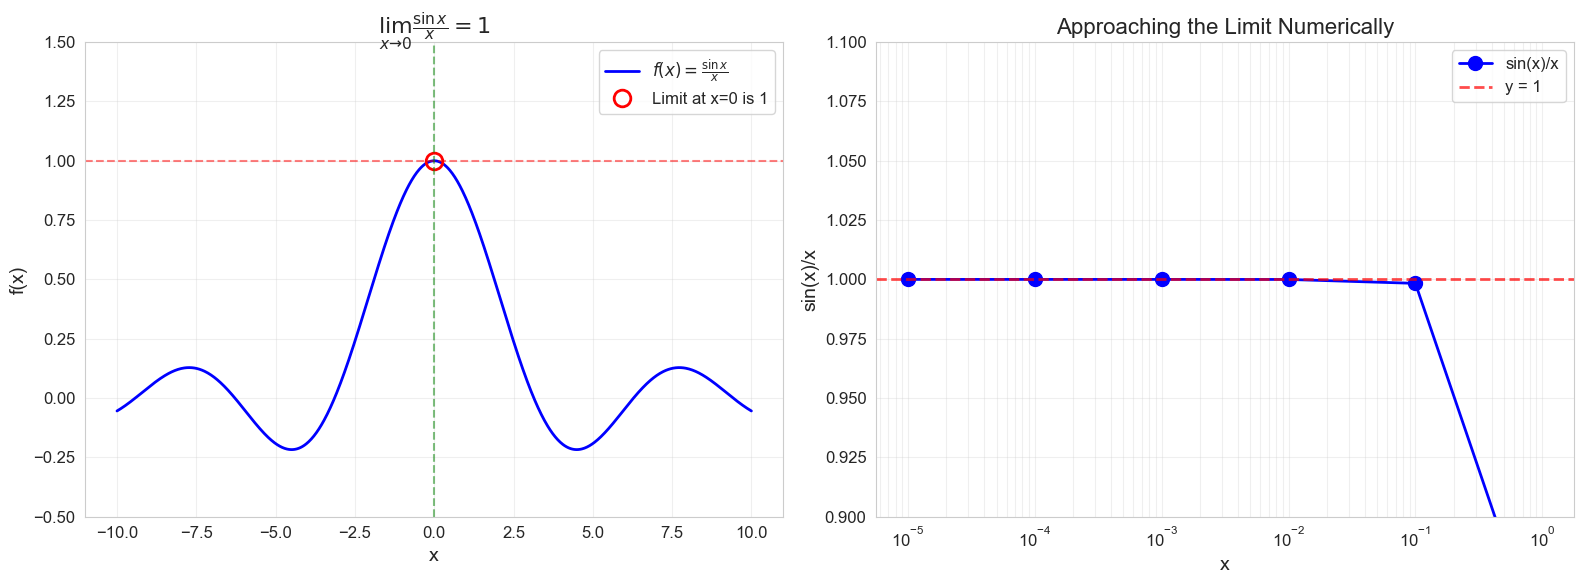

Numerical approach to the limit:
  x =  1.00000  →  sin(x)/x = 0.8414709848
  x =  0.10000  →  sin(x)/x = 0.9983341665
  x =  0.01000  →  sin(x)/x = 0.9999833334
  x =  0.00100  →  sin(x)/x = 0.9999998333
  x =  0.00010  →  sin(x)/x = 0.9999999983
  x =  0.00001  →  sin(x)/x = 1.0000000000

The limit is exactly 1!


In [8]:
# Visualize sin(x)/x
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: The function
x = np.linspace(-10, 10, 1000)
x_nonzero = x[x != 0]
y = np.sin(x_nonzero) / x_nonzero

ax1.plot(x_nonzero, y, 'b-', linewidth=2, label=r'$f(x) = \frac{\sin x}{x}$')
ax1.plot(0, 1, 'ro', markersize=12, fillstyle='none', markeredgewidth=2, 
         label='Limit at x=0 is 1')
ax1.axhline(y=1, color='r', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='g', linestyle='--', alpha=0.5)
ax1.set_xlabel('x', fontsize=14)
ax1.set_ylabel('f(x)', fontsize=14)
ax1.set_title(r'$\lim_{x \to 0} \frac{\sin x}{x} = 1$', fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.5, 1.5)

# Right plot: Numerical verification
x_vals = np.array([1, 0.1, 0.01, 0.001, 0.0001, 0.00001])
y_vals = np.sin(x_vals) / x_vals

ax2.plot(x_vals, y_vals, 'bo-', linewidth=2, markersize=10, label='sin(x)/x')
ax2.axhline(y=1, color='r', linestyle='--', linewidth=2, alpha=0.7, label='y = 1')
ax2.set_xlabel('x', fontsize=14)
ax2.set_ylabel('sin(x)/x', fontsize=14)
ax2.set_title('Approaching the Limit Numerically', fontsize=16)
ax2.set_xscale('log')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_ylim(0.9, 1.1)

plt.tight_layout()
plt.show()

# Numerical demonstration
print("Numerical approach to the limit:")
for x_val in [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]:
    y_val = np.sin(x_val) / x_val
    print(f"  x = {x_val:8.5f}  →  sin(x)/x = {y_val:.10f}")
print("\nThe limit is exactly 1!")

### The Squeeze Theorem

If $g(x) \leq f(x) \leq h(x)$ near $a$, and $\lim_{x \to a} g(x) = \lim_{x \to a} h(x) = L$,

then $\lim_{x \to a} f(x) = L$

**Intuition**: If f(x) is squeezed between two functions that both approach L, then f(x) must also approach L!

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vy/p9y7fvld08b5lgvfkc6n_s8h0000gn/T/ipykernel_24368/3134591825.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Squeeze Theorem: $-x^2 \leq x^2\sin(1/x) \leq x^2$', fontsize=16)


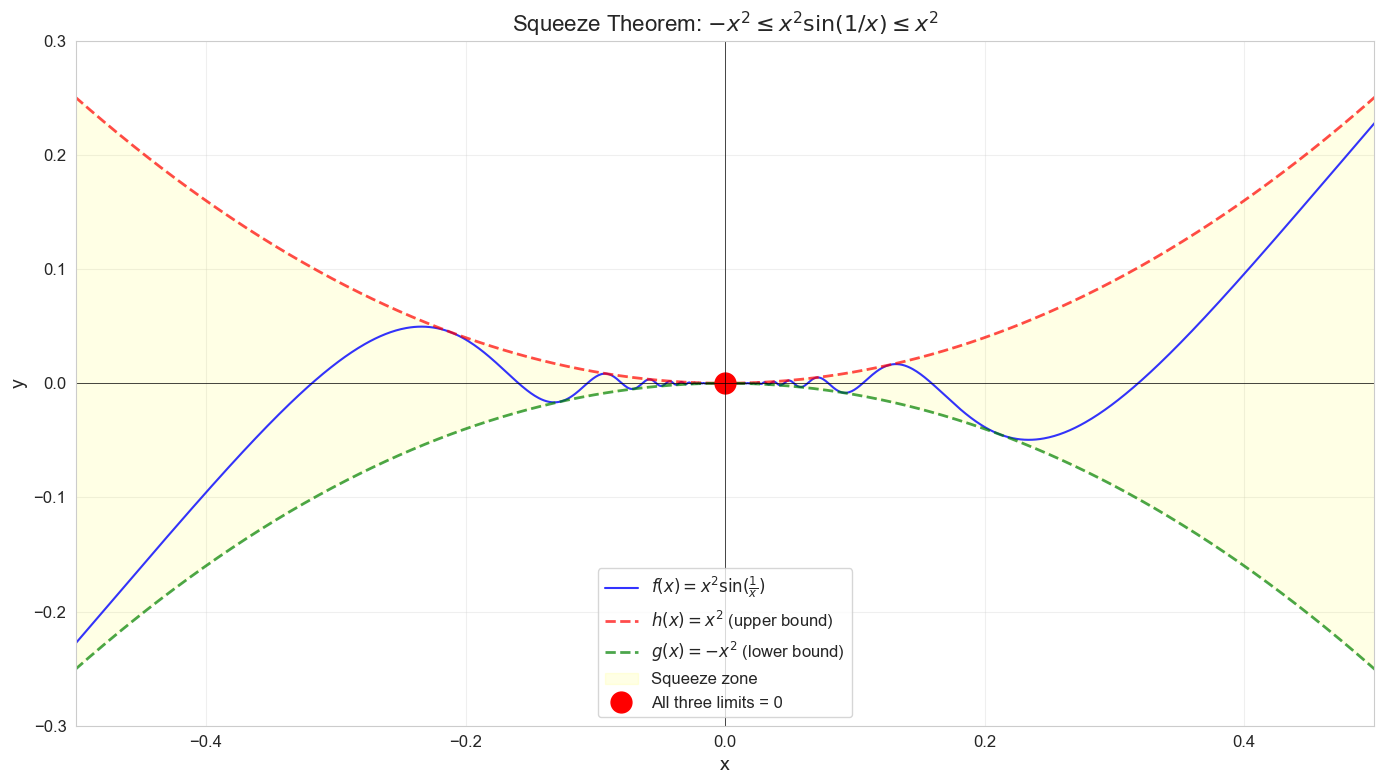

The Squeeze Theorem in action:
  Since -1 ≤ sin(1/x) ≤ 1 for all x ≠ 0,
  we have -x² ≤ x²sin(1/x) ≤ x²
  As x → 0, both -x² and x² approach 0
  Therefore, x²sin(1/x) must also approach 0!


In [9]:
# Classic example: x^2 * sin(1/x) as x → 0
x = np.linspace(-1, 1, 2000)
x_nonzero = x[x != 0]

# The function
f = x_nonzero**2 * np.sin(1/x_nonzero)

# The bounding functions
upper = x**2
lower = -x**2

plt.figure(figsize=(14, 8))
plt.plot(x_nonzero, f, 'b-', linewidth=1.5, label=r'$f(x) = x^2 \sin(\frac{1}{x})$', alpha=0.8)
plt.plot(x, upper, 'r--', linewidth=2, label=r'$h(x) = x^2$ (upper bound)', alpha=0.7)
plt.plot(x, lower, 'g--', linewidth=2, label=r'$g(x) = -x^2$ (lower bound)', alpha=0.7)
plt.fill_between(x, lower, upper, alpha=0.1, color='yellow', label='Squeeze zone')
plt.plot(0, 0, 'ro', markersize=15, label='All three limits = 0')

plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.title('Squeeze Theorem: $-x^2 \leq x^2\sin(1/x) \leq x^2$', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 0.5)
plt.ylim(-0.3, 0.3)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("The Squeeze Theorem in action:")
print("  Since -1 ≤ sin(1/x) ≤ 1 for all x ≠ 0,")
print("  we have -x² ≤ x²sin(1/x) ≤ x²")
print("  As x → 0, both -x² and x² approach 0")
print("  Therefore, x²sin(1/x) must also approach 0!")

## 6. Continuity

A function $f$ is **continuous** at $x = a$ if:

1. $f(a)$ is defined
2. $\lim_{x \to a} f(x)$ exists
3. $\lim_{x \to a} f(x) = f(a)$

**Intuition**: You can draw the function without lifting your pencil!

### Types of Discontinuities:

1. **Removable**: The limit exists but $f(a)$ is either not defined or not equal to the limit
2. **Jump**: Left and right limits exist but are different
3. **Infinite**: The function approaches ±∞
4. **Oscillating**: The function oscillates too much (e.g., $\sin(1/x)$ as $x \to 0$)

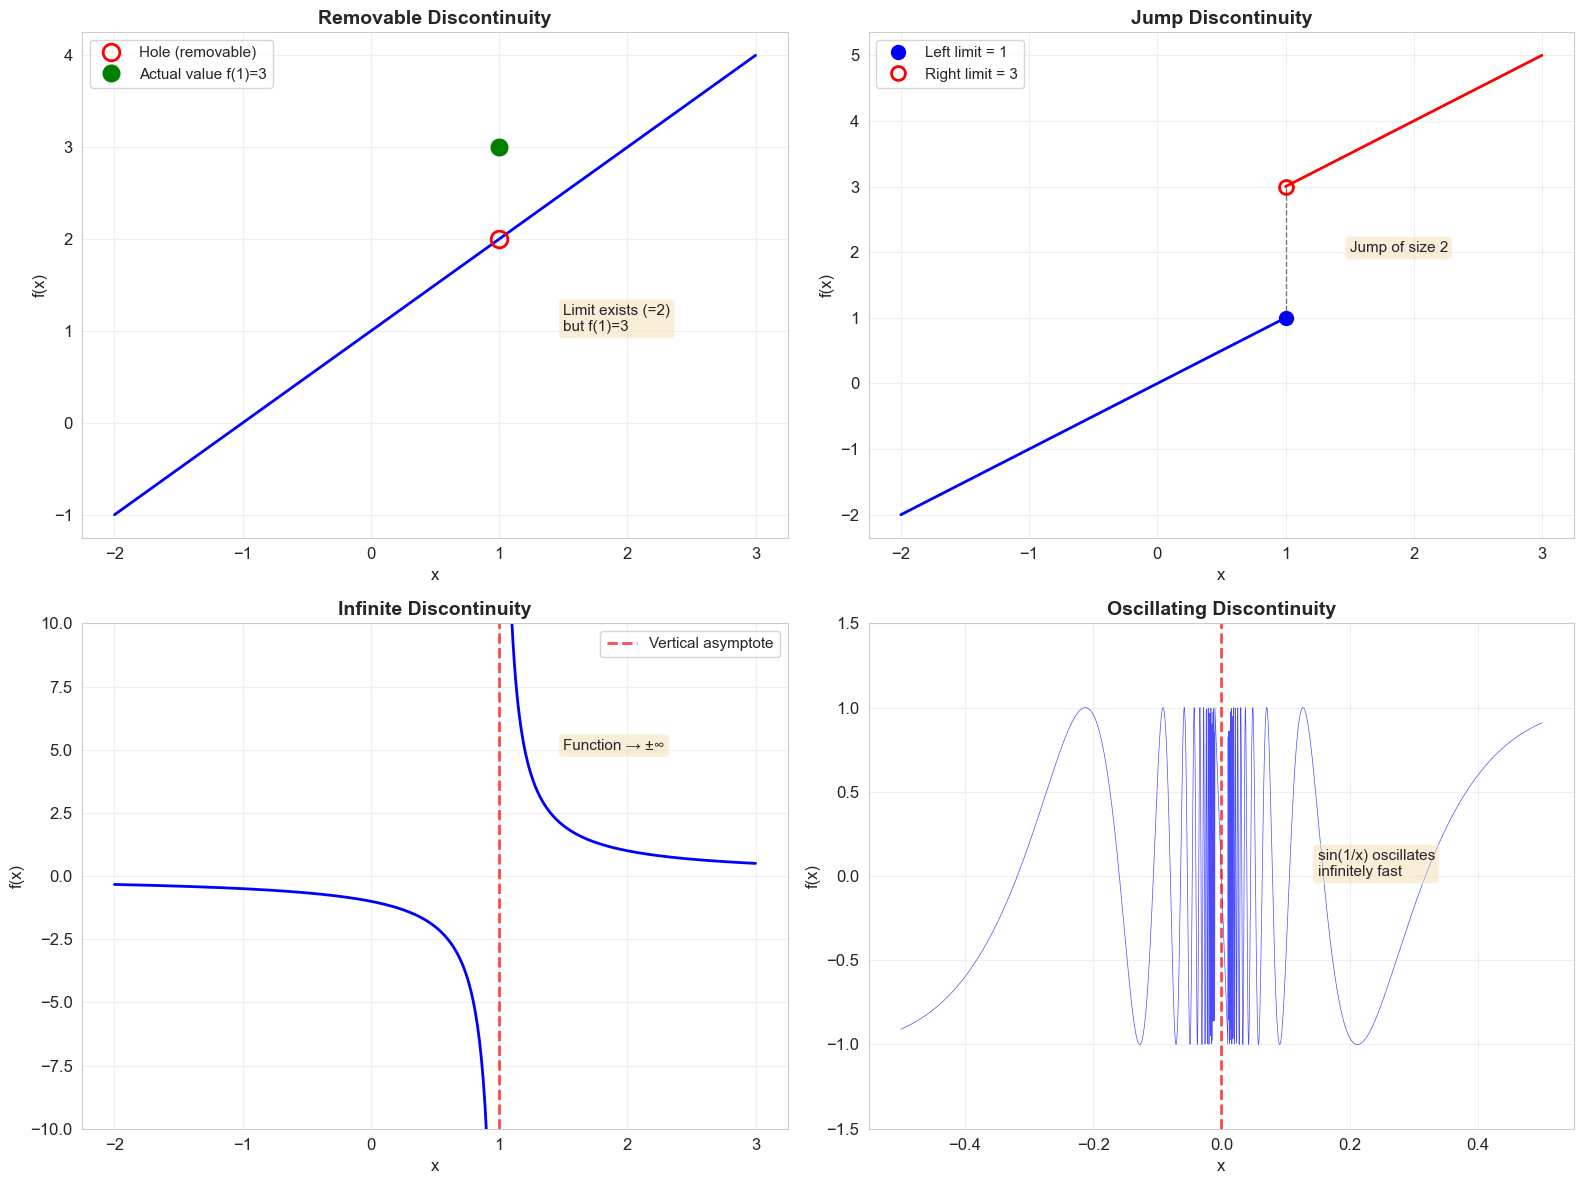

In [10]:
# Visualize types of discontinuities
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Removable discontinuity
x1 = np.linspace(-2, 3, 1000)
x1_plot = x1[np.abs(x1 - 1) > 0.01]
y1 = (x1_plot**2 - 1) / (x1_plot - 1)

axes[0, 0].plot(x1_plot, y1, 'b-', linewidth=2)
axes[0, 0].plot(1, 2, 'ro', markersize=12, fillstyle='none', markeredgewidth=2, 
                label='Hole (removable)')
axes[0, 0].plot(1, 3, 'go', markersize=12, label='Actual value f(1)=3')
axes[0, 0].set_title('Removable Discontinuity', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('x', fontsize=12)
axes[0, 0].set_ylabel('f(x)', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(1.5, 1, 'Limit exists (=2)\nbut f(1)=3', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Jump discontinuity
x2a = np.linspace(-2, 1, 100)
x2b = np.linspace(1, 3, 100)
y2a = x2a
y2b = x2b + 2

axes[0, 1].plot(x2a, y2a, 'b-', linewidth=2)
axes[0, 1].plot(x2b, y2b, 'r-', linewidth=2)
axes[0, 1].plot(1, 1, 'bo', markersize=10, label='Left limit = 1')
axes[0, 1].plot(1, 3, 'ro', markersize=10, fillstyle='none', markeredgewidth=2, 
                label='Right limit = 3')
axes[0, 1].plot([1, 1], [1, 3], 'k--', linewidth=1, alpha=0.5)
axes[0, 1].set_title('Jump Discontinuity', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('x', fontsize=12)
axes[0, 1].set_ylabel('f(x)', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].text(1.5, 2, 'Jump of size 2', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Infinite discontinuity
x3a = np.linspace(-2, 0.95, 200)
x3b = np.linspace(1.05, 3, 200)
y3a = 1 / (x3a - 1)
y3b = 1 / (x3b - 1)

axes[1, 0].plot(x3a, y3a, 'b-', linewidth=2)
axes[1, 0].plot(x3b, y3b, 'b-', linewidth=2)
axes[1, 0].axvline(x=1, color='r', linestyle='--', linewidth=2, alpha=0.7, 
                   label='Vertical asymptote')
axes[1, 0].set_title('Infinite Discontinuity', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('x', fontsize=12)
axes[1, 0].set_ylabel('f(x)', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(-10, 10)
axes[1, 0].text(1.5, 5, 'Function → ±∞', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Oscillating discontinuity
x4 = np.linspace(-0.5, 0.5, 5000)
x4_nonzero = x4[np.abs(x4) > 0.01]
y4 = np.sin(1 / x4_nonzero)

axes[1, 1].plot(x4_nonzero, y4, 'b-', linewidth=0.5, alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 1].set_title('Oscillating Discontinuity', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('x', fontsize=12)
axes[1, 1].set_ylabel('f(x)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(-1.5, 1.5)
axes[1, 1].text(0.15, 0, 'sin(1/x) oscillates\ninfinitely fast', fontsize=11, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. Practice Problems

### Problem 1: Evaluate $\lim_{x \to 2} \frac{x^2 - 4}{x - 2}$

**Solution**:

In [11]:
print("Problem 1: lim(x→2) (x²-4)/(x-2)")
print("\nStep 1: Direct substitution gives 0/0 (indeterminate)")
print("Step 2: Factor the numerator: x²-4 = (x+2)(x-2)")
print("Step 3: Simplify: (x+2)(x-2)/(x-2) = x+2 for x≠2")
print("Step 4: Take the limit: lim(x→2) (x+2) = 2+2 = 4")
print("\nAnswer: 4")

# Verify numerically
print("\nNumerical verification:")
for x in [1.9, 1.99, 1.999, 2.001, 2.01, 2.1]:
    val = (x**2 - 4) / (x - 2)
    print(f"  x = {x:6.3f}  →  f(x) = {val:.6f}")

Problem 1: lim(x→2) (x²-4)/(x-2)

Step 1: Direct substitution gives 0/0 (indeterminate)
Step 2: Factor the numerator: x²-4 = (x+2)(x-2)
Step 3: Simplify: (x+2)(x-2)/(x-2) = x+2 for x≠2
Step 4: Take the limit: lim(x→2) (x+2) = 2+2 = 4

Answer: 4

Numerical verification:
  x =  1.900  →  f(x) = 3.900000
  x =  1.990  →  f(x) = 3.990000
  x =  1.999  →  f(x) = 3.999000
  x =  2.001  →  f(x) = 4.001000
  x =  2.010  →  f(x) = 4.010000
  x =  2.100  →  f(x) = 4.100000


### Problem 2: Evaluate $\lim_{x \to \infty} \frac{3x^2 + 5x - 1}{2x^2 - x + 7}$

**Solution**:

Problem 2: lim(x→∞) (3x²+5x-1)/(2x²-x+7)

Step 1: Both numerator and denominator → ∞
Step 2: Divide every term by x² (highest power):
        = (3 + 5/x - 1/x²) / (2 - 1/x + 7/x²)
Step 3: As x→∞, terms with x in denominator → 0
        = (3 + 0 - 0) / (2 - 0 + 0) = 3/2

Answer: 3/2 = 1.5

Numerical verification:
  x =     10  →  f(x) = 1.7715736041
  x =    100  →  f(x) = 1.5320741448
  x =   1000  →  f(x) = 1.5032458616
  x =  10000  →  f(x) = 1.5003249587
  x = 100000  →  f(x) = 1.5000324996


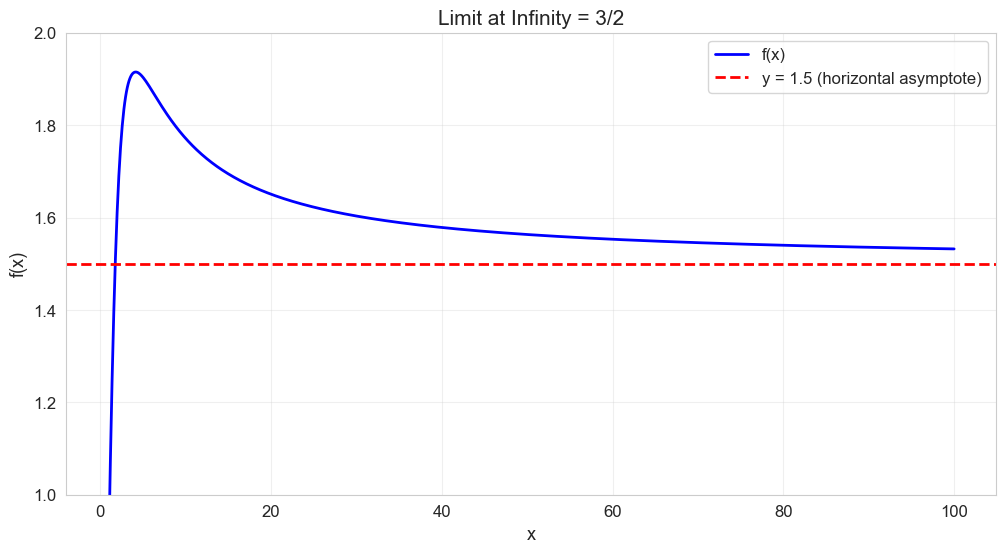

In [12]:
print("Problem 2: lim(x→∞) (3x²+5x-1)/(2x²-x+7)")
print("\nStep 1: Both numerator and denominator → ∞")
print("Step 2: Divide every term by x² (highest power):")
print("        = (3 + 5/x - 1/x²) / (2 - 1/x + 7/x²)")
print("Step 3: As x→∞, terms with x in denominator → 0")
print("        = (3 + 0 - 0) / (2 - 0 + 0) = 3/2")
print("\nAnswer: 3/2 = 1.5")

# Verify numerically and visually
print("\nNumerical verification:")
for x in [10, 100, 1000, 10000, 100000]:
    val = (3*x**2 + 5*x - 1) / (2*x**2 - x + 7)
    print(f"  x = {x:6.0f}  →  f(x) = {val:.10f}")

# Plot
x = np.linspace(1, 100, 1000)
y = (3*x**2 + 5*x - 1) / (2*x**2 - x + 7)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2, label='f(x)')
plt.axhline(y=1.5, color='r', linestyle='--', linewidth=2, label='y = 1.5 (horizontal asymptote)')
plt.xlabel('x', fontsize=13)
plt.ylabel('f(x)', fontsize=13)
plt.title('Limit at Infinity = 3/2', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(1, 2)
plt.show()

### Problem 3: Evaluate $\lim_{h \to 0} \frac{(x+h)^2 - x^2}{h}$

This is the **definition of the derivative** of $x^2$!

**Solution**:

Problem 3: lim(h→0) [(x+h)² - x²]/h

This is the derivative of x² at any point x!

Step 1: Expand (x+h)²:
        = [x² + 2xh + h² - x²] / h
Step 2: Simplify:
        = [2xh + h²] / h
Step 3: Factor out h:
        = h(2x + h) / h = 2x + h (for h≠0)
Step 4: Take limit as h→0:
        = 2x + 0 = 2x

Answer: 2x

This tells us: the derivative of x² is 2x!


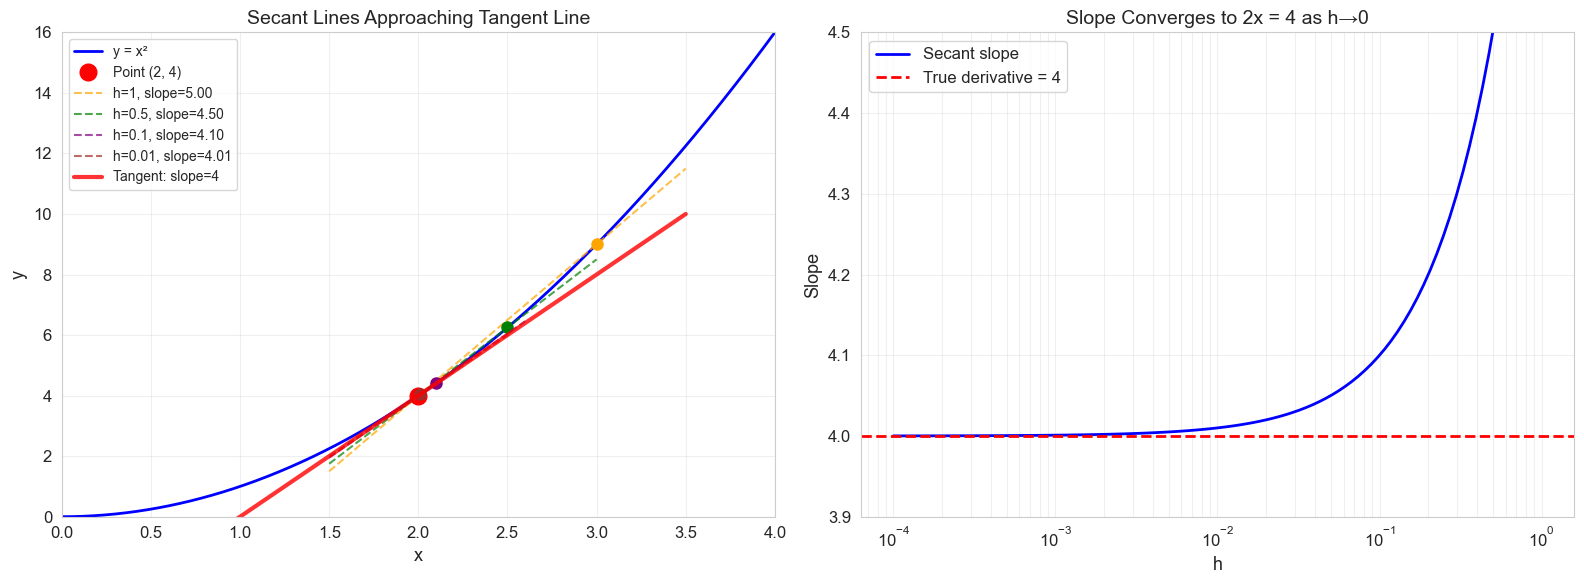

In [13]:
print("Problem 3: lim(h→0) [(x+h)² - x²]/h")
print("\nThis is the derivative of x² at any point x!")
print("\nStep 1: Expand (x+h)²:")
print("        = [x² + 2xh + h² - x²] / h")
print("Step 2: Simplify:")
print("        = [2xh + h²] / h")
print("Step 3: Factor out h:")
print("        = h(2x + h) / h = 2x + h (for h≠0)")
print("Step 4: Take limit as h→0:")
print("        = 2x + 0 = 2x")
print("\nAnswer: 2x")
print("\nThis tells us: the derivative of x² is 2x!")

# Visualize this geometrically
x_val = 2  # Let's use x = 2 as an example
h_values = [1, 0.5, 0.1, 0.01]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Show the secant lines approaching the tangent
x_plot = np.linspace(0, 4, 1000)
y_plot = x_plot**2

axes[0].plot(x_plot, y_plot, 'b-', linewidth=2, label='y = x²')
axes[0].plot(x_val, x_val**2, 'ro', markersize=12, label=f'Point ({x_val}, {x_val**2})')

colors = ['orange', 'green', 'purple', 'brown']
for i, h in enumerate(h_values):
    x2 = x_val + h
    y2 = x2**2
    slope = ((x_val + h)**2 - x_val**2) / h
    
    # Plot secant line
    x_line = np.linspace(x_val - 0.5, x_val + h + 0.5, 100)
    y_line = x_val**2 + slope * (x_line - x_val)
    axes[0].plot(x_line, y_line, '--', color=colors[i], alpha=0.7, linewidth=1.5,
                label=f'h={h}, slope={slope:.2f}')
    axes[0].plot(x2, y2, 'o', color=colors[i], markersize=8)

# True tangent line (slope = 2x = 4)
true_slope = 2 * x_val
x_tangent = np.linspace(0.5, 3.5, 100)
y_tangent = x_val**2 + true_slope * (x_tangent - x_val)
axes[0].plot(x_tangent, y_tangent, 'r-', linewidth=3, alpha=0.8, 
            label=f'Tangent: slope={true_slope}')

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Secant Lines Approaching Tangent Line', fontsize=14)
axes[0].legend(fontsize=10, loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 4)
axes[0].set_ylim(0, 16)

# Right: Show how the slope converges
h_range = np.logspace(-4, 0, 100)
slopes = ((x_val + h_range)**2 - x_val**2) / h_range

axes[1].plot(h_range, slopes, 'b-', linewidth=2, label='Secant slope')
axes[1].axhline(y=true_slope, color='r', linestyle='--', linewidth=2, 
               label=f'True derivative = {true_slope}')
axes[1].set_xlabel('h', fontsize=13)
axes[1].set_ylabel('Slope', fontsize=13)
axes[1].set_title(f'Slope Converges to 2x = {true_slope} as h→0', fontsize=14)
axes[1].set_xscale('log')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3, which='both')
axes[1].set_ylim(3.9, 4.5)

plt.tight_layout()
plt.show()

## 8. Key Takeaways

### Why Limits are Crucial for Calculus:

1. **Derivatives** are defined as limits:
   $$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

2. **Integrals** are defined as limits of Riemann sums:
   $$\int_a^b f(x)\,dx = \lim_{n \to \infty} \sum_{i=1}^n f(x_i^*) \Delta x$$

3. **Continuity** is defined using limits - essential for understanding when functions behave nicely

### Computational Strategies:

1. **Direct substitution** - try it first!
2. **Factoring** - for polynomial ratios giving 0/0
3. **Conjugate multiplication** - for square roots
4. **Limit laws** - break complex limits into pieces
5. **L'Hôpital's Rule** - for indeterminate forms (we'll cover this in differentiation!)
6. **Special limits** - memorize $\lim_{x \to 0} \frac{\sin x}{x} = 1$

### Common Mistakes to Avoid:

- Confusing $\lim_{x \to a} f(x)$ with $f(a)$ - they can be different!
- Forgetting to check one-sided limits
- Dividing by zero incorrectly
- Not recognizing indeterminate forms like 0/0, ∞/∞

---

**Next Up**: We'll explore Functions in detail, understanding domains, ranges, compositions, and transformations - all essential for applying calculus techniques!